In [1]:
!wget https://raw.githubusercontent.com/The-CEAS-Library/Data-Analysis-with-Python-Linear-Regression/main/auto.csv

--2026-06-08 17:57:00--  https://raw.githubusercontent.com/The-CEAS-Library/Data-Analysis-with-Python-Linear-Regression/main/auto.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 25045 (24K) [text/plain]
Saving to: ‘auto.csv’

auto.csv            100%[===================>]  24.46K  --.-KB/s    in 0.002s  

2026-06-08 17:57:00 (14.5 MB/s) - ‘auto.csv’ saved [25045/25045]



In [2]:
import pandas as pd
import numpy as np

automobile = pd.read_csv('auto.csv')

# Replace any missing values with NaNs
automobile.replace('?', np.nan, inplace = True)

# Drop the NaNs, reset the index and drop the unnecessary columns
auto_df = automobile.dropna().reset_index().drop(['index','symboling'],axis=1)

# Change the datatype of a column as per the requirement
auto_df[['price','horsepower']] = auto_df[['price','horsepower']].astype(dtype = 'float64')

###**Exercise 1**

* Establish a relationship between the **'curb weight'** (independent variable) and the **'city mpg'** (dependent variable) of the automobile.
  * Use simple linear regression.
  * Evaluate the performance of the model by calculating the R$^2$  value, the  mean squared error between the actual and predicted values from the respective model.
  * Plot the best-fit line.


Intercept:  48.756379166512176
Slope:  [-0.00905348]
Mean Squared Error: 25.49955792961944
R2 Value: 0.5004582403257962


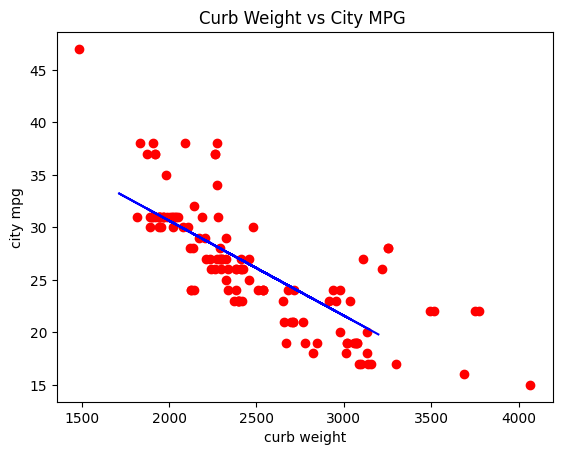

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


X = auto_df[['curb weight']]
y = auto_df['city mpg']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train the model
model = LinearRegression().fit(X_train, y_train)

# Print intercept and slope:
print("Intercept: ", model.intercept_)
print("Slope: ", model.coef_)

# Predicting the values
y_pred = model.predict(X_test)

# Evaluating the model

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Value:', r2_score(y_test, y_pred))

# Visualizing the training Test Results
plt.scatter(X_train, y_train, color= 'red')
plt.plot(X_test, y_pred, color = 'blue')
plt.title('Curb Weight vs City MPG ')
plt.ylabel('city mpg')
plt.xlabel('curb weight')
plt.show()



###**Exercise 2**

* Create a linear regression model to predict the **'city mpg'** of an automobile using multiple features: **curb weight**, **engine size**, **horsepower**.
  * Use multiple linear regression to train the model
  * Evaluate the model by printing the error metrics, R$^2$  value
  * Predict the **'city mpg'** for a given set of following test values:<br>
    * **curb weight** : 3500
    * **engine size** : 180
    * **horsepower** : 160


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split


X = auto_df[['curb weight','engine size','horsepower']]
y = auto_df['city mpg']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Train the model
model = LinearRegression().fit(X_train, y_train)

# Print intercept and slope:
print("Intercept: ", model.intercept_)
print("Slope: ", model.coef_)

# Predicting the values
y_pred = model.predict(X_test)

# Evaluating the model

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R2 Value:', r2_score(y_test, y_pred))

test_values = [3500, 180, 160]

# Mulit-linear regression equation

city_mpg = model.coef_[0] * test_values[0] + model.coef_[1] * test_values[1] + model.coef_[2] * test_values[2] + model.intercept_

print('City mileage for the test values: ', city_mpg)

Intercept:  46.76993043313882
Slope:  [-0.00562668  0.06169705 -0.1461892 ]
Mean Squared Error: 18.49319685246173
R2 Value: 0.6377143430024141
City mileage for the test values:  14.791737669890274


###**Exercise 3**

* Create a polynomial regression model to predict the **'price'** of an automobile using multiple features that have not yet been used. Use the heatmap to choose an appropriate variable. Feel free to adjust things like train_size, the number of features, and the degree to produce the best performing model. Keep train_size between 0.6 and 0.8.
  * Use polynomial regression.
  * Evaluate the performance of the model by calculating the R$^2$  value, the  mean squared error between the actual and predicted values from the respective model.
  * Plot the actual vs predicted graphs.

Value of R-squared:  0.6438242423761333
Root Mean Squared Error:  6338015.838582124


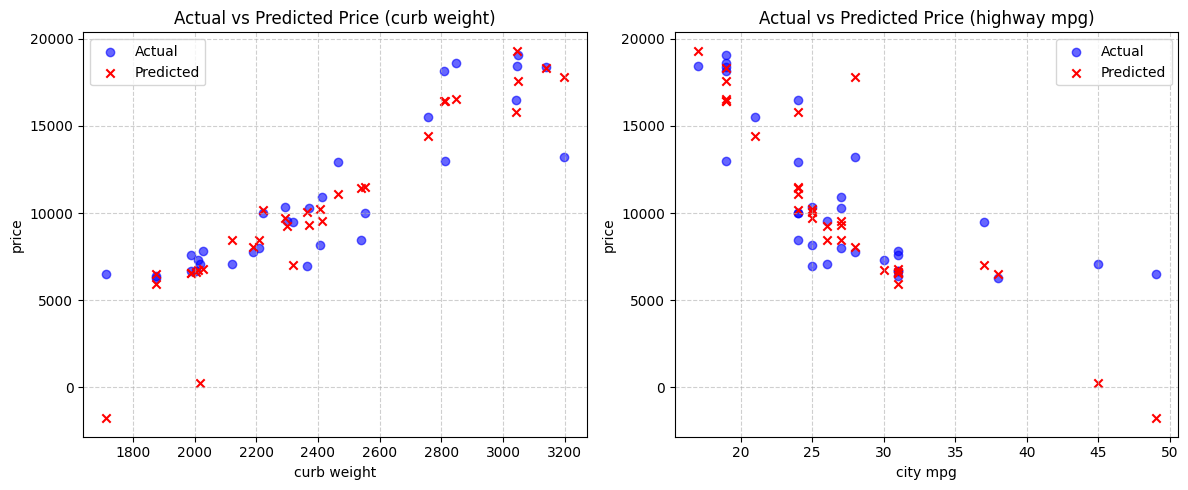

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

x3 = auto_df[['curb weight', 'city mpg']]
y3= auto_df['price']


x3_train, x3_test, y3_train, y3_test = train_test_split(x3, y3, train_size = 0.8, random_state = 42)

poly = PolynomialFeatures(degree=3, include_bias = False)

x3_train_poly = poly.fit_transform(x3_train)
x3_test_poly = poly.fit_transform(x3_test)

poly_model = LinearRegression().fit(x3_train_poly, y3_train)

y3_pred = poly_model.predict(x3_test_poly)

r_sq = r2_score(y3_test, y3_pred)

print("Value of R-squared: ", r_sq)

mse3 = mean_squared_error(y3_test, y3_pred)

print("Root Mean Squared Error: ", mse3)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.scatter(x3_test['curb weight'], y3_test, color='blue', alpha=0.6, label="Actual")
plt.scatter(x3_test['curb weight'], y3_pred, color='red', marker='x', label="Predicted")
plt.xlabel("curb weight")
plt.ylabel("price")
plt.title("Actual vs Predicted Price (curb weight)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.subplot(1,2,2)
plt.scatter(x3_test['city mpg'], y3_test, color='blue', alpha=0.6, label="Actual")
plt.scatter(x3_test['city mpg'], y3_pred, color='red', marker='x', label="Predicted")
plt.xlabel("city mpg")
plt.ylabel("price")
plt.title("Actual vs Predicted Price (highway mpg)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()